# Phishing URL Classification — Exploratory Data Analysis

**Dataset:** `phishing_urls.csv` (~235K URLs, 53 features + label)

**Label:** 1 = legitimate, 0 = phishing

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

## 1. Load Data

In [21]:
df = pd.read_csv('../data/processed/cleaned_phishing_urls.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (235795, 52)


,URLLength,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,...,0,0,1,10,2,7,42,2,5,1


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 52 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URLLength                   235795 non-null  int64  
 1   DomainLength                235795 non-null  int64  
 2   IsDomainIP                  235795 non-null  int64  
 3   TLD                         235795 non-null  str    
 4   URLSimilarityIndex          235795 non-null  float64
 5   CharContinuationRate        235795 non-null  float64
 6   TLDLegitimateProb           235795 non-null  float64
 7   URLCharProb                 235795 non-null  float64
 8   TLDLength                   235795 non-null  int64  
 9   NoOfSubDomain               235795 non-null  int64  
 10  HasObfuscation              235795 non-null  int64  
 11  NoOfObfuscatedChar          235795 non-null  int64  
 12  ObfuscationRatio            235795 non-null  float64
 13  NoOfLettersInURL         

## 2. Label Distribution

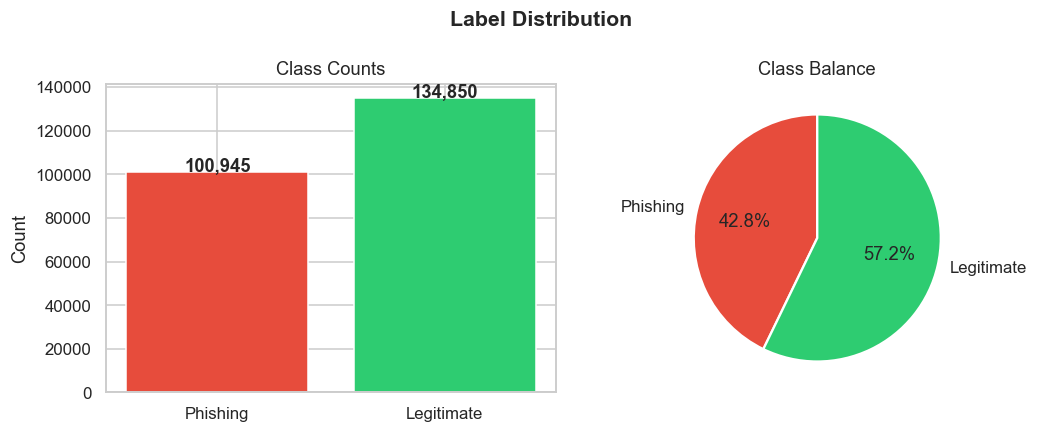

             count    pct
label                    
Phishing    100945  42.81
Legitimate  134850  57.19


In [23]:
label_counts = df['label'].value_counts().sort_index()
label_map = {0: 'Phishing', 1: 'Legitimate'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([label_map[k] for k in label_counts.index], label_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Count')

axes[1].pie(label_counts.values, labels=[label_map[k] for k in label_counts.index],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance')

plt.suptitle('Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(label_counts.rename(label_map).to_frame('count').assign(
    pct=lambda x: (x['count'] / x['count'].sum() * 100).round(2)
))

## 4. Numerical Feature Summary

In [24]:
# Separate feature groups
drop_cols = ['URL', 'Domain', 'Title', 'label']
num_cols = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=np.number).columns.tolist()

# Binary (0/1) vs continuous
binary_cols = [c for c in num_cols if df[c].nunique() <= 2]
cont_cols   = [c for c in num_cols if c not in binary_cols]

print(f'Total numeric features : {len(num_cols)}')
print(f'Binary (0/1)           : {len(binary_cols)}')
print(f'Continuous             : {len(cont_cols)}')

display(df[cont_cols].describe().T.round(3))

Total numeric features : 50
Binary (0/1)           : 19
Continuous             : 31


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573,41.314,13.000,23.000,27.000,34.000,6.097000e+03
DomainLength,235795.0,21.470,9.151,4.000,16.000,20.000,24.000,1.100000e+02
URLSimilarityIndex,235795.0,78.431,28.976,0.156,57.025,100.000,100.000,1.000000e+02
CharContinuationRate,235795.0,0.846,0.217,0.000,0.680,1.000,1.000,1.000000e+00
TLDLegitimateProb,235795.0,0.260,0.252,0.000,0.006,0.080,0.523,5.230000e-01
URLCharProb,235795.0,0.056,0.011,0.001,0.051,0.058,0.063,9.100000e-02
TLDLength,235795.0,2.764,0.600,2.000,2.000,3.000,3.000,1.300000e+01
NoOfSubDomain,235795.0,1.165,0.601,0.000,1.000,1.000,1.000,1.000000e+01
NoOfObfuscatedChar,235795.0,0.025,1.876,0.000,0.000,0.000,0.000,4.470000e+02
ObfuscationRatio,235795.0,0.000,0.004,0.000,0.000,0.000,0.000,3.480000e-01


## 5. Distribution of Continuous Features by Label

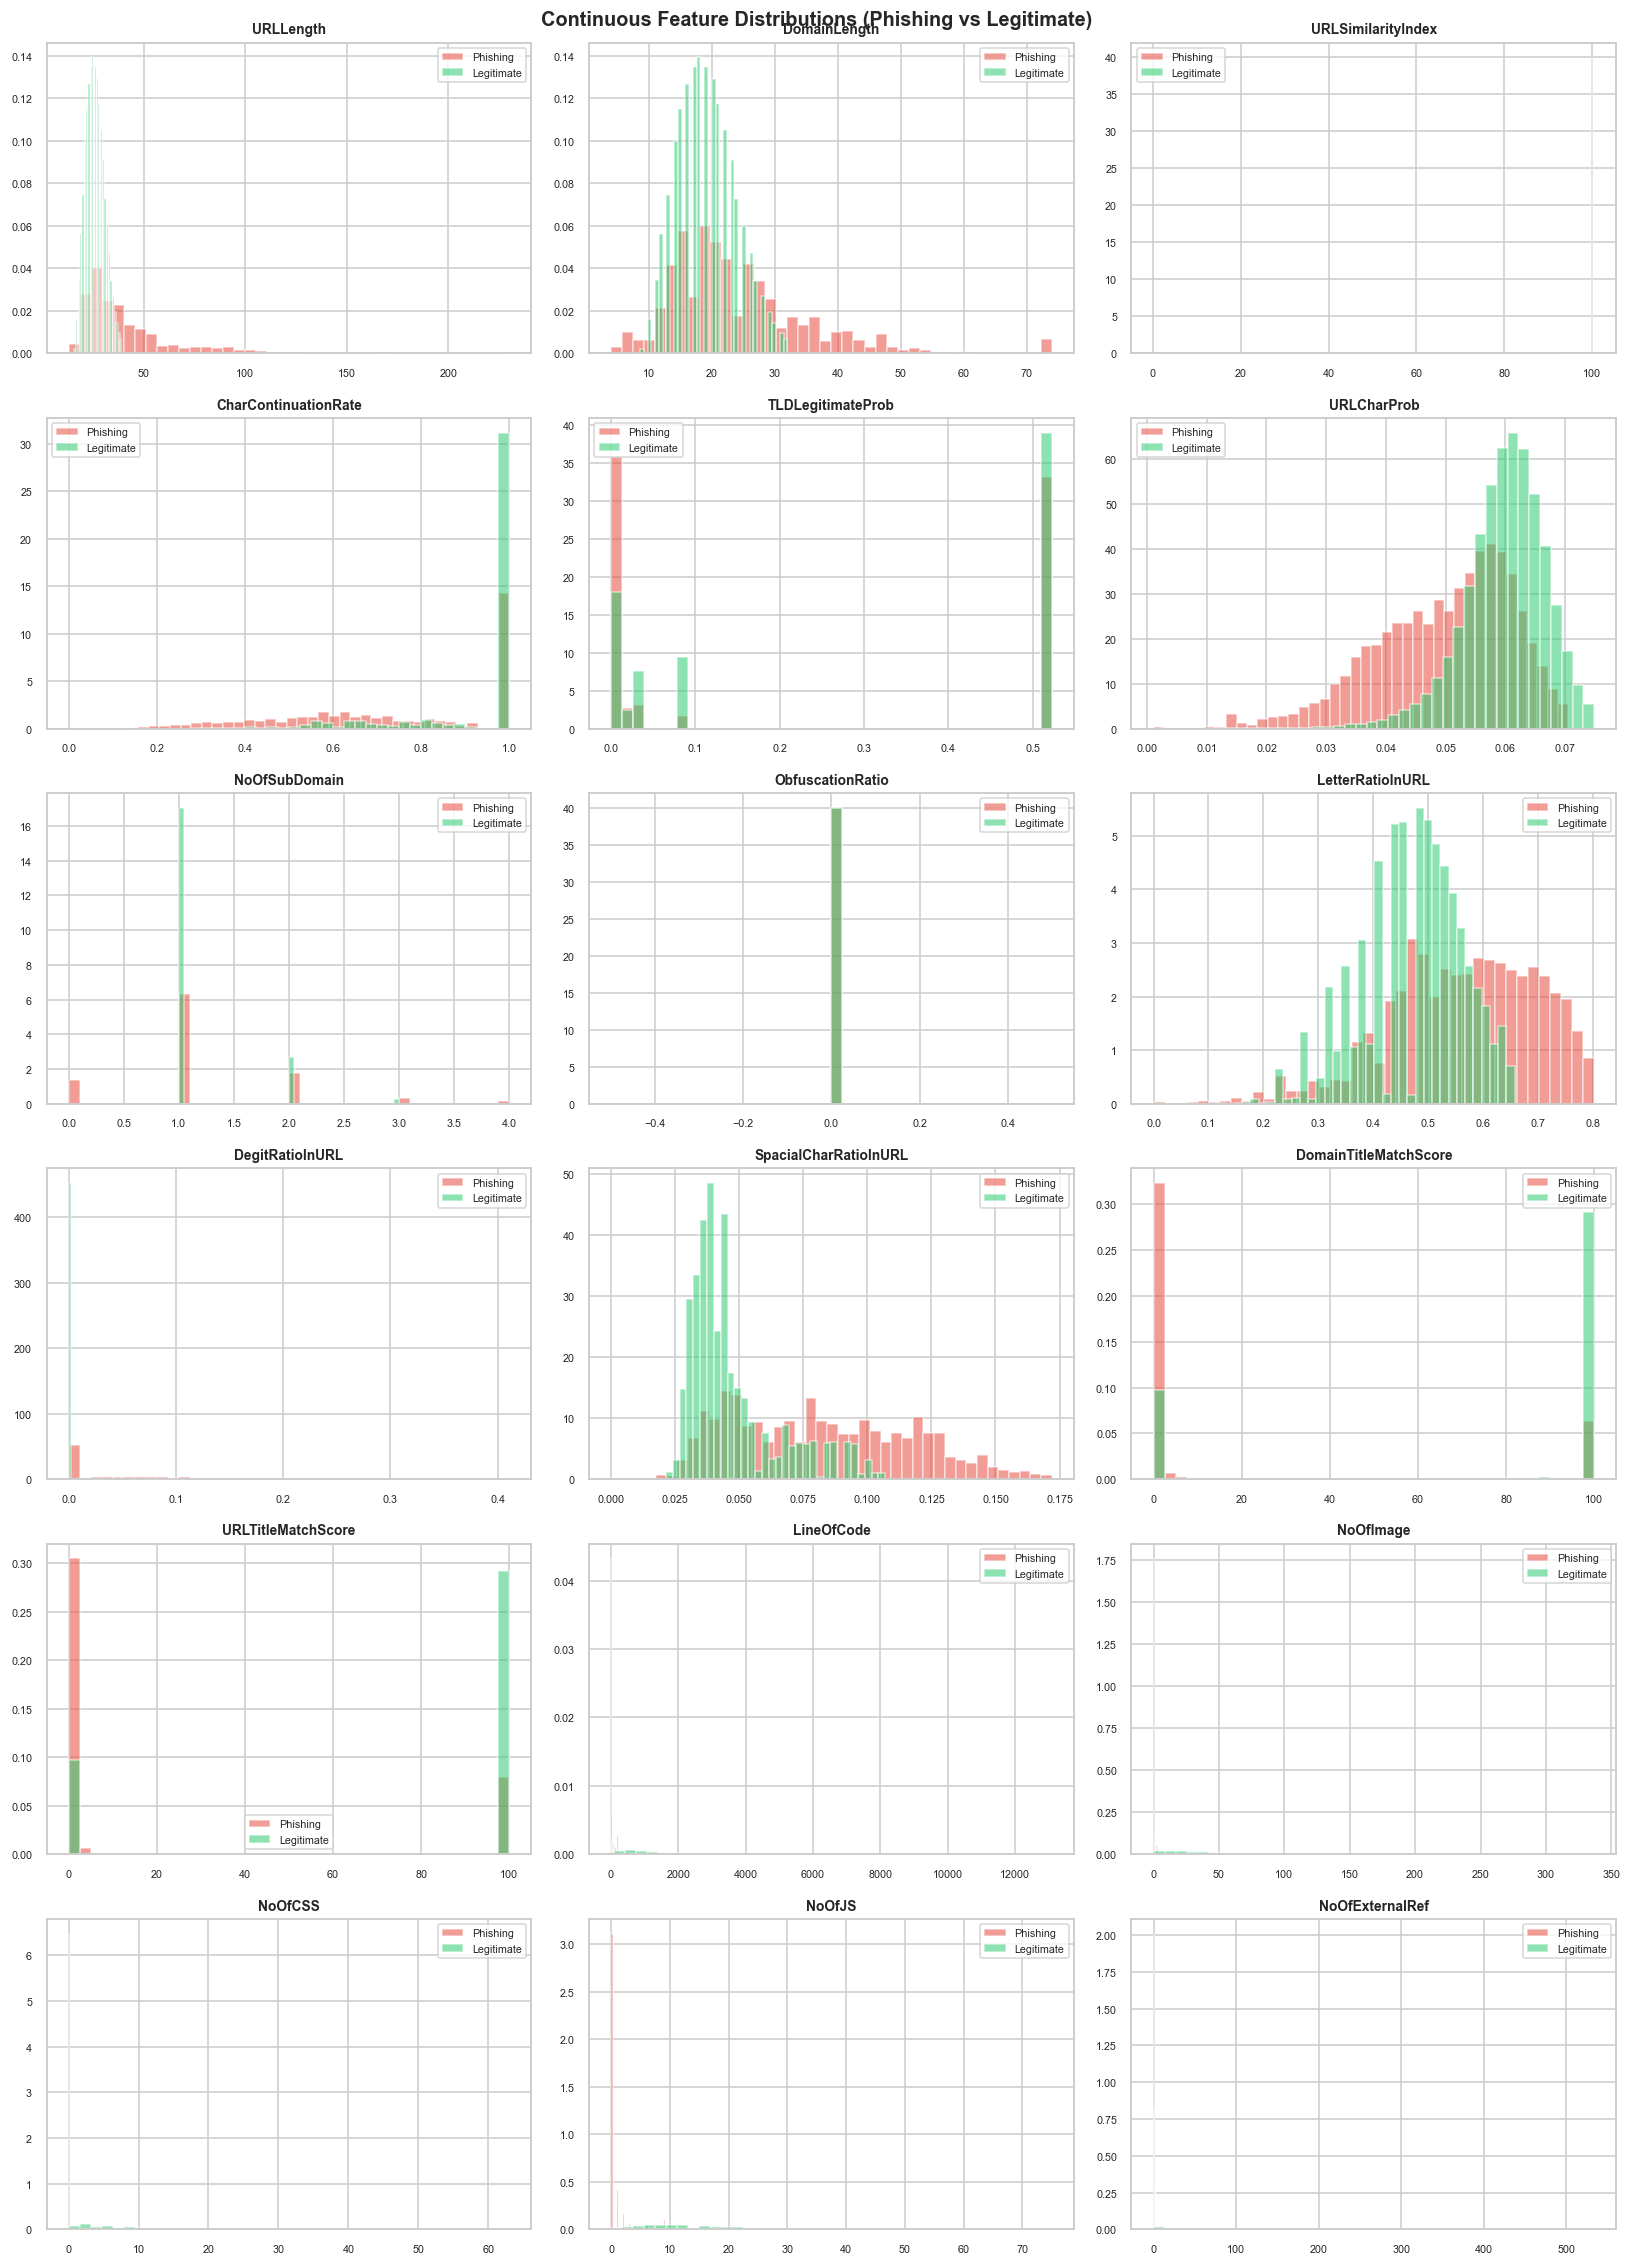

In [25]:
# Key continuous features to visualise
key_cont = [
    'URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate',
    'TLDLegitimateProb', 'URLCharProb', 'NoOfSubDomain', 'ObfuscationRatio',
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL',
    'DomainTitleMatchScore', 'URLTitleMatchScore', 'LineOfCode',
    'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfExternalRef'
]
key_cont = [c for c in key_cont if c in df.columns]

n_cols = 3
n_rows = -(-len(key_cont) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

colors = {0: '#e74c3c', 1: '#2ecc71'}
labels_map = {0: 'Phishing', 1: 'Legitimate'}

for ax, col in zip(axes, key_cont):
    for lbl in [0, 1]:
        subset = df[df['label'] == lbl][col].dropna()
        # cap at 99th pct for readability
        cap = subset.quantile(0.99)
        subset = subset[subset <= cap]
        ax.hist(subset, bins=40, alpha=0.55, color=colors[lbl],
                label=labels_map[lbl], density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for ax in axes[len(key_cont):]:
    ax.set_visible(False)

plt.suptitle('Continuous Feature Distributions (Phishing vs Legitimate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Binary Feature Rates by Label

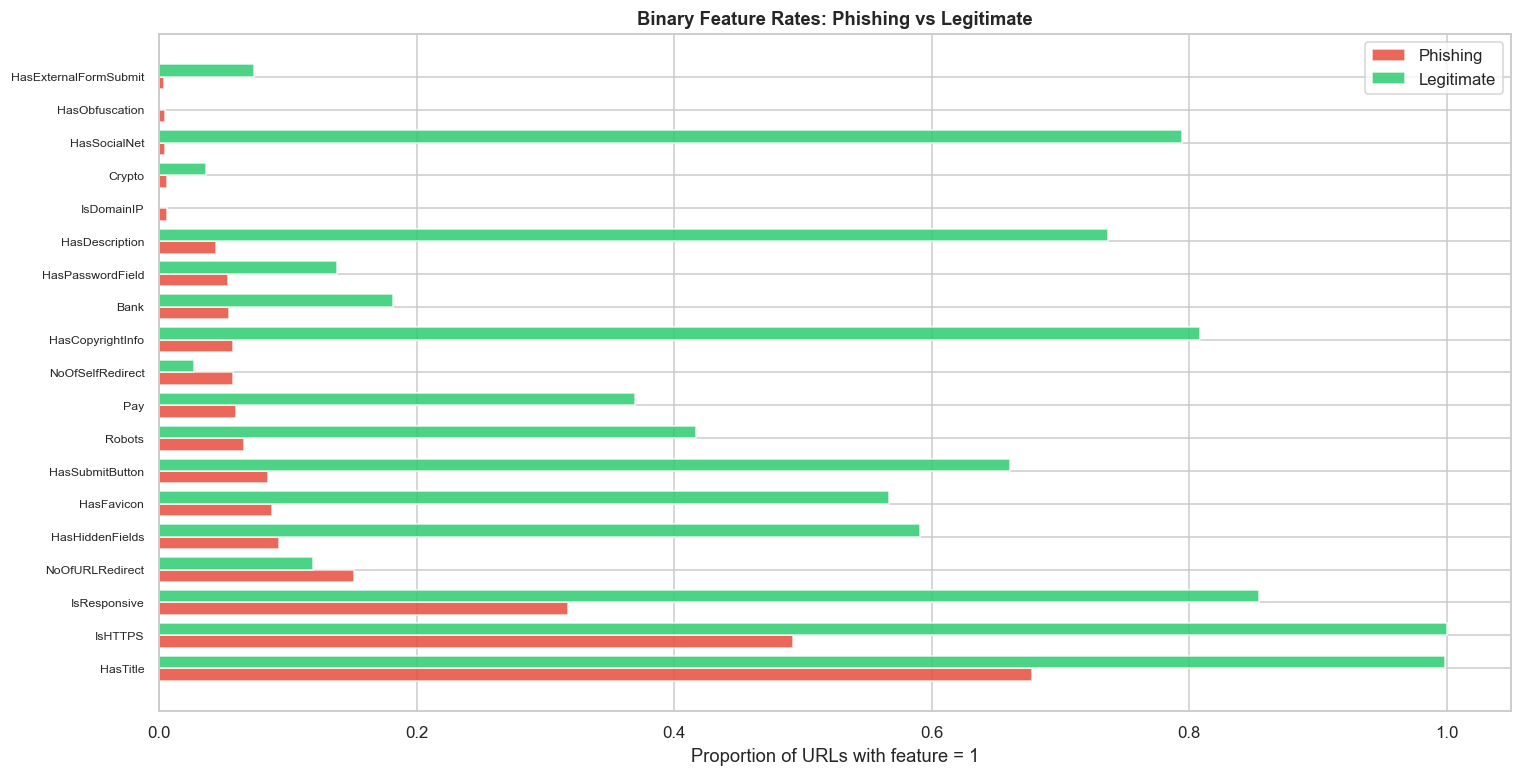

Top 10 most discriminating binary features:


label,Phishing,Legitimate,diff
HasSocialNet,0.005,0.795,0.789
HasCopyrightInfo,0.057,0.808,0.751
HasDescription,0.044,0.737,0.692
HasSubmitButton,0.085,0.661,0.576
IsResponsive,0.317,0.854,0.537
IsHTTPS,0.492,1.000,0.508
HasHiddenFields,0.093,0.591,0.498
HasFavicon,0.088,0.567,0.479
Robots,0.066,0.417,0.351
HasTitle,0.678,0.999,0.321


In [26]:
binary_rates = (
    df[binary_cols + ['label']]
    .groupby('label')[binary_cols]
    .mean()
    .T
    .rename(columns={0: 'Phishing', 1: 'Legitimate'})
    .sort_values('Phishing', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, max(5, len(binary_cols) * 0.38)))
x = np.arange(len(binary_rates))
w = 0.38
ax.barh(x - w/2, binary_rates['Phishing'],   w, label='Phishing',   color='#e74c3c', alpha=0.85)
ax.barh(x + w/2, binary_rates['Legitimate'], w, label='Legitimate', color='#2ecc71', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(binary_rates.index, fontsize=8)
ax.set_xlabel('Proportion of URLs with feature = 1')
ax.set_title('Binary Feature Rates: Phishing vs Legitimate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Show top discriminating features
binary_rates['diff'] = (binary_rates['Legitimate'] - binary_rates['Phishing']).abs()
print('Top 10 most discriminating binary features:')
display(binary_rates.sort_values('diff', ascending=False).head(10).round(3))

## 7. Box Plots — Key Continuous Features

/var/folders/pf/xn094ngs70lb3jh0xpvlzx8c0000gn/T/ipykernel_82295/3675135077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_ph[data_ph <= cap], data_le[data_le <= cap]],
/var/folders/pf/xn094ngs70lb3jh0xpvlzx8c0000gn/T/ipykernel_82295/3675135077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_ph[data_ph <= cap], data_le[data_le <= cap]],
/var/folders/pf/xn094ngs70lb3jh0xpvlzx8c0000gn/T/ipykernel_82295/3675135077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_ph[data_ph <= cap], data_le[data_le <= cap]],
/var/folders/pf/xn094ngs70lb3jh0xpvlzx8c0000gn/T/

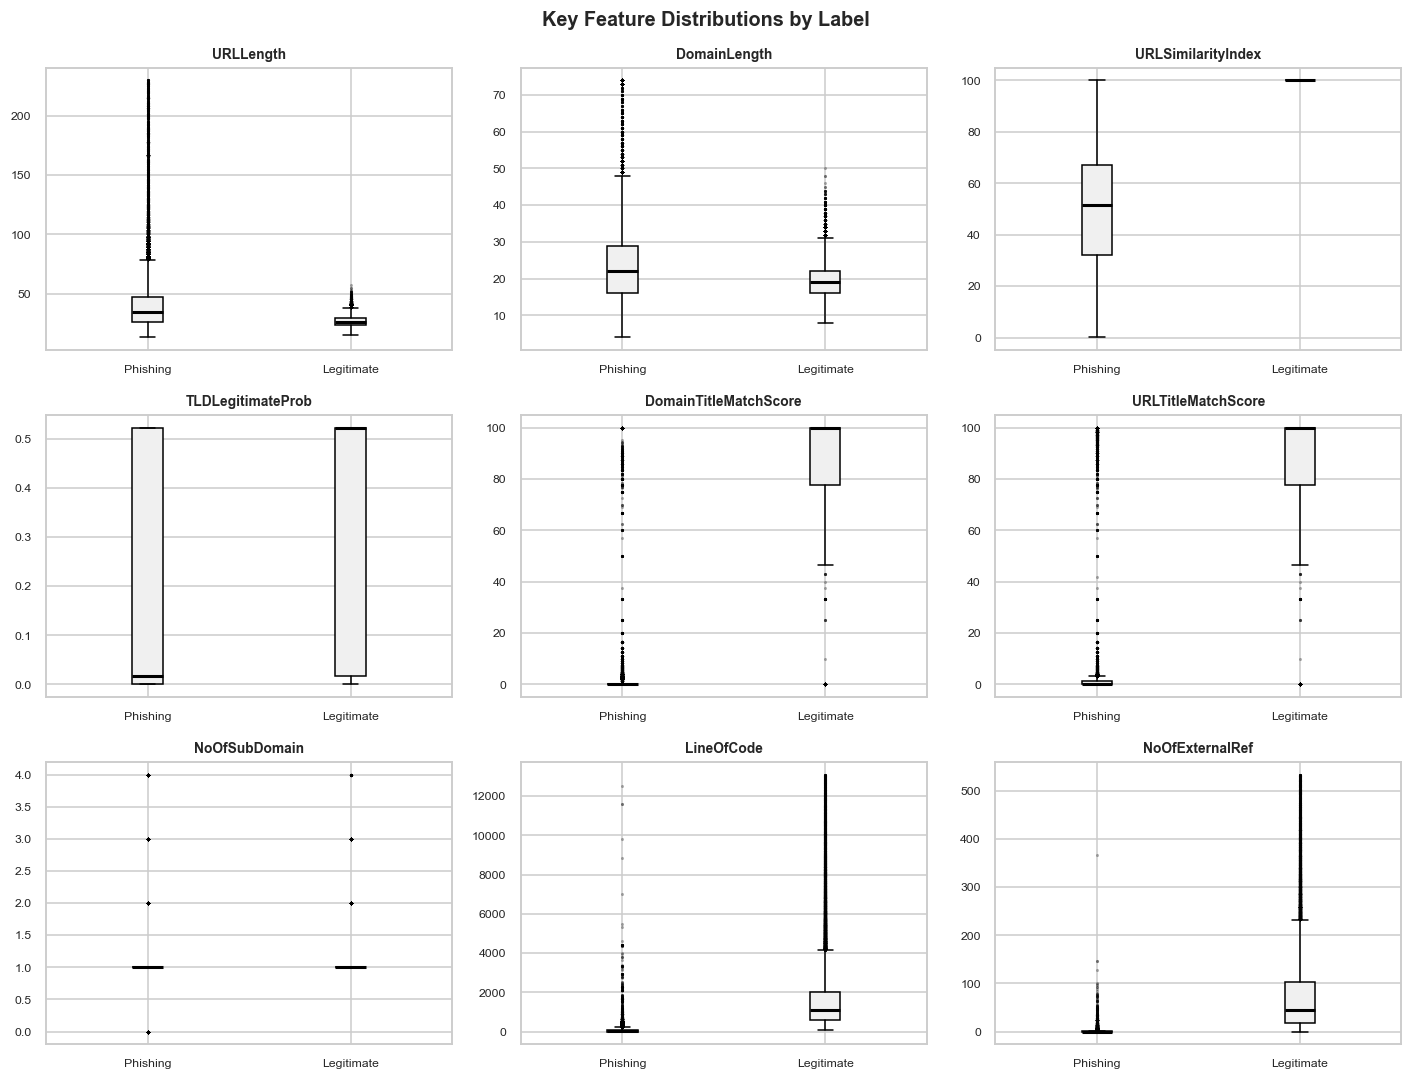

In [27]:
box_features = ['URLLength', 'DomainLength', 'URLSimilarityIndex',
                'TLDLegitimateProb', 'DomainTitleMatchScore', 'URLTitleMatchScore',
                'NoOfSubDomain', 'LineOfCode', 'NoOfExternalRef']
box_features = [c for c in box_features if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for ax, col in zip(axes, box_features):
    data_ph = df[df['label'] == 0][col].dropna()
    data_le = df[df['label'] == 1][col].dropna()
    # cap outliers
    cap = max(data_ph.quantile(0.99), data_le.quantile(0.99))
    ax.boxplot([data_ph[data_ph <= cap], data_le[data_le <= cap]],
               labels=['Phishing', 'Legitimate'],
               patch_artist=True,
               boxprops=dict(facecolor='#f0f0f0'),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

for ax in axes[len(box_features):]:
    ax.set_visible(False)

plt.suptitle('Key Feature Distributions by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Correlation with Label

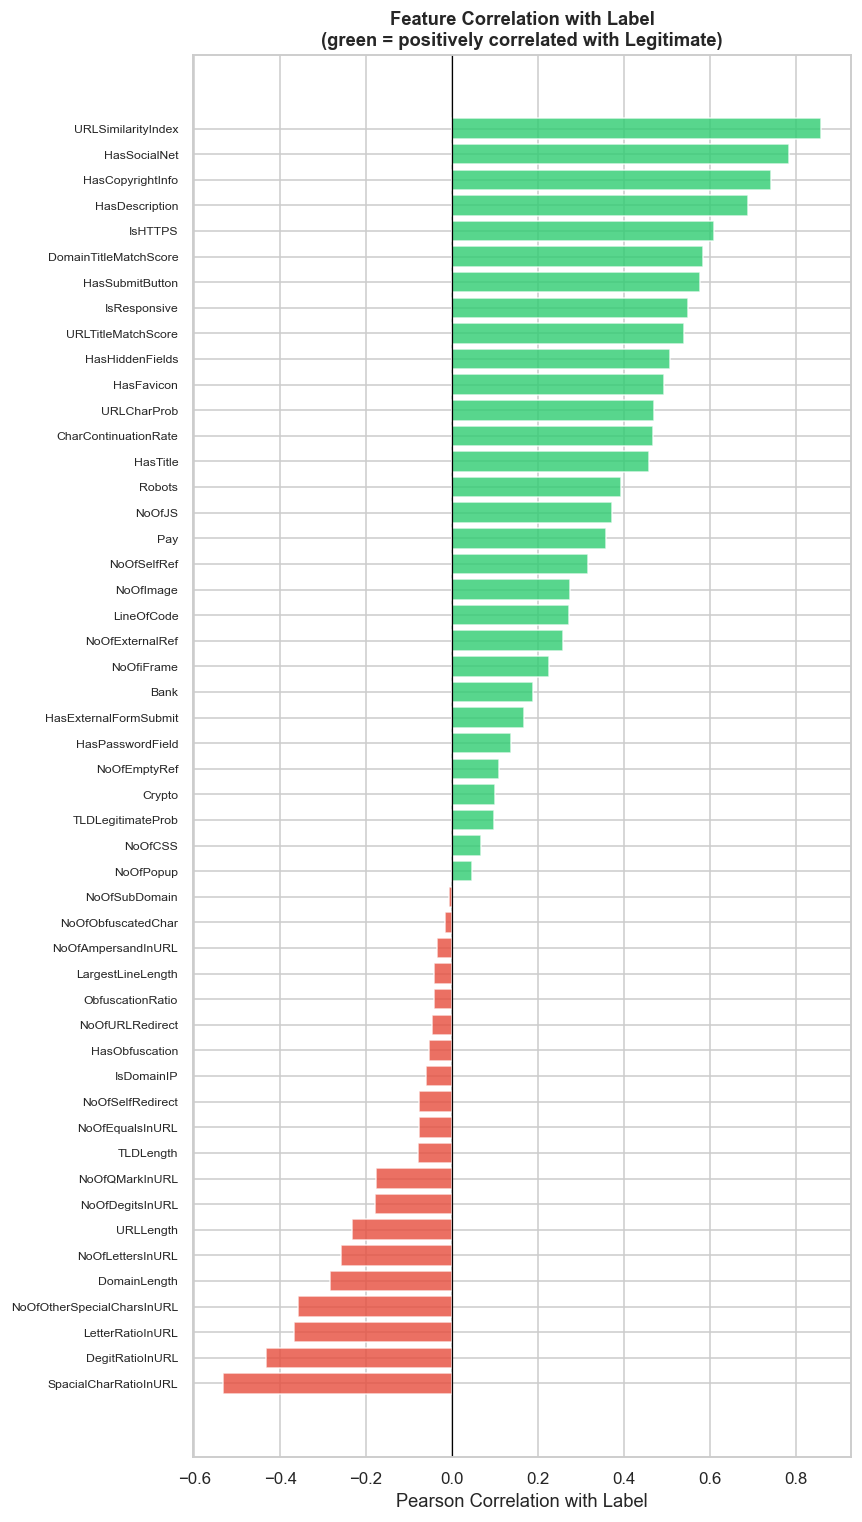

Top 10 positive (legitimate indicators):
HasHiddenFields          0.508
URLTitleMatchScore       0.539
IsResponsive             0.549
HasSubmitButton          0.579
DomainTitleMatchScore    0.585
IsHTTPS                  0.609
HasDescription           0.690
HasCopyrightInfo         0.743
HasSocialNet             0.784
URLSimilarityIndex       0.860

Top 10 negative (phishing indicators):
SpacialCharRatioInURL        -0.534
DegitRatioInURL              -0.432
LetterRatioInURL             -0.368
NoOfOtherSpecialCharsInURL   -0.359
DomainLength                 -0.283
NoOfLettersInURL             -0.258
URLLength                    -0.233
NoOfDegitsInURL              -0.178
NoOfQMarkInURL               -0.176
TLDLength                    -0.079


In [28]:
corr_with_label = df[num_cols + ['label']].corr()['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(8, max(6, len(corr_with_label) * 0.28)))
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_label.values]
ax.barh(corr_with_label.index, corr_with_label.values, color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Label')
ax.set_title('Feature Correlation with Label\n(green = positively correlated with Legitimate)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print('Top 10 positive (legitimate indicators):')
print(corr_with_label.tail(10).round(3).to_string())
print('\nTop 10 negative (phishing indicators):')
print(corr_with_label.head(10).round(3).to_string())

## 9. Feature Correlation Matrix (Top Features)

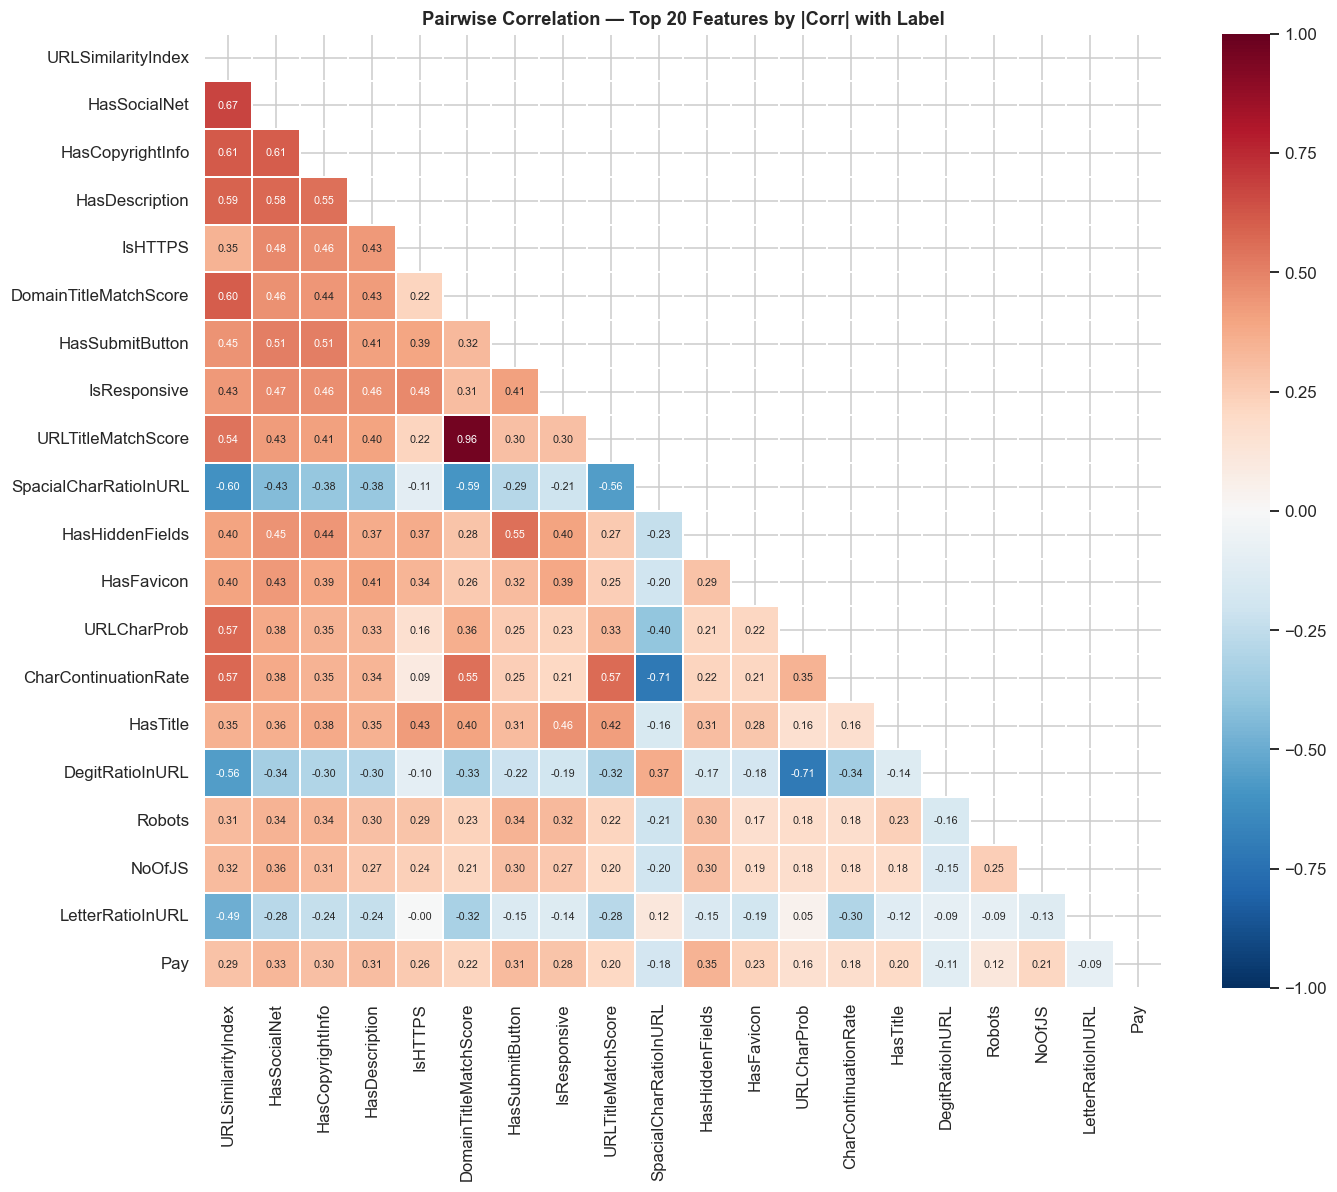

In [29]:
# Use top 20 most correlated with label
top_features = corr_with_label.abs().nlargest(20).index.tolist()

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Pairwise Correlation — Top 20 Features by |Corr| with Label', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. TLD Analysis

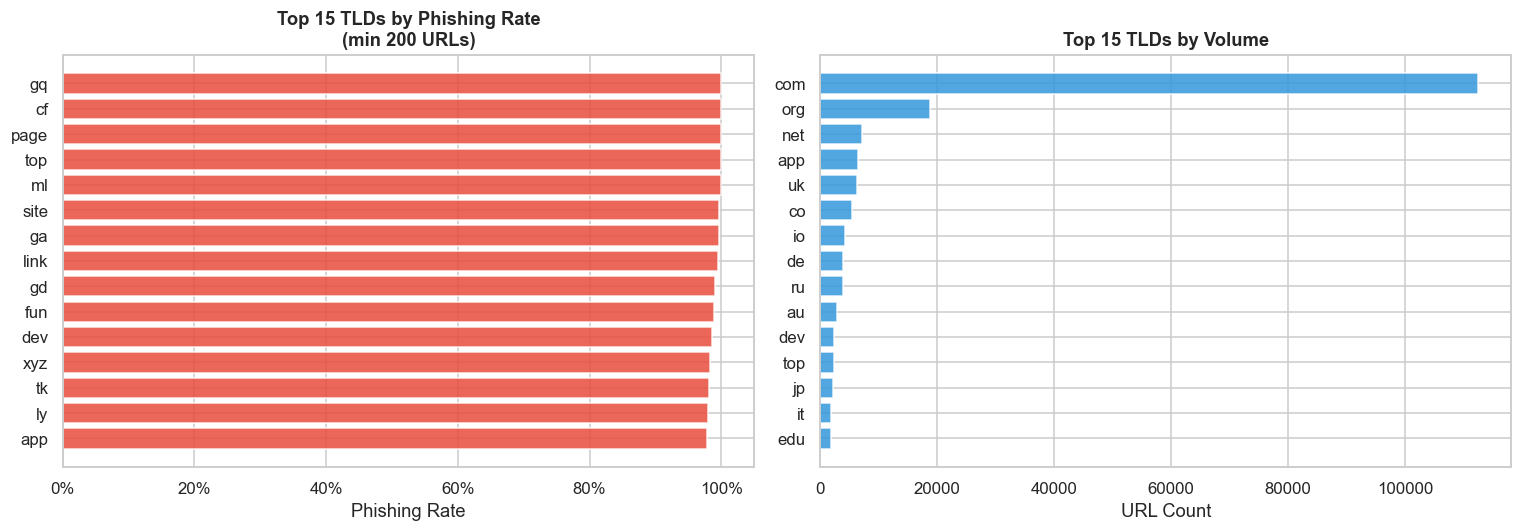

Unique TLDs in dataset: 695


,count,phishing_rate
TLD,,
gq,493,1.000
cf,1203,1.000
page,490,1.000
top,2329,0.999
ml,995,0.999
site,1482,0.997
ga,1111,0.996
link,1463,0.995
gd,327,0.991


In [30]:
tld_stats = (
    df.groupby('TLD')
    .agg(count=('label', 'size'), phishing_rate=('label', lambda x: (x == 0).mean()))
    .query('count >= 200')
    .sort_values('phishing_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top TLDs by phishing rate
top_ph = tld_stats.head(15)
axes[0].barh(top_ph.index[::-1], top_ph['phishing_rate'][::-1], color='#e74c3c', alpha=0.85)
axes[0].set_xlabel('Phishing Rate')
axes[0].set_title('Top 15 TLDs by Phishing Rate\n(min 200 URLs)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Top TLDs by volume
top_vol = tld_stats.sort_values('count', ascending=False).head(15)
axes[1].barh(top_vol.index[::-1], top_vol['count'][::-1], color='#3498db', alpha=0.85)
axes[1].set_xlabel('URL Count')
axes[1].set_title('Top 15 TLDs by Volume', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Unique TLDs in dataset: {df["TLD"].nunique()}')
display(tld_stats.head(10).round(3))

## 11. URL Length & Obfuscation Deep Dive

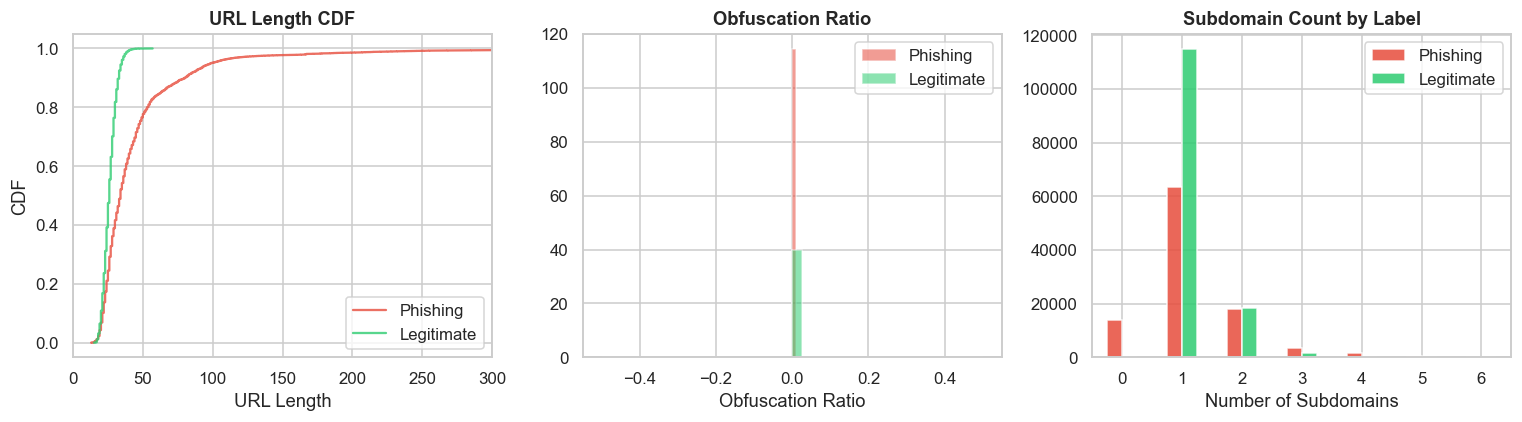

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# URL length CDF
for lbl, color, name in [(0, '#e74c3c', 'Phishing'), (1, '#2ecc71', 'Legitimate')]:
    vals = df[df['label'] == lbl]['URLLength'].sort_values()
    axes[0].plot(vals.values, np.linspace(0, 1, len(vals)), color=color, label=name, alpha=0.8)
axes[0].set_xlabel('URL Length')
axes[0].set_ylabel('CDF')
axes[0].set_title('URL Length CDF', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Obfuscation ratio distribution
for lbl, color, name in [(0, '#e74c3c', 'Phishing'), (1, '#2ecc71', 'Legitimate')]:
    subset = df[df['label'] == lbl]['ObfuscationRatio']
    axes[1].hist(subset, bins=40, density=True, alpha=0.55, color=color, label=name)
axes[1].set_xlabel('Obfuscation Ratio')
axes[1].set_title('Obfuscation Ratio', fontweight='bold')
axes[1].legend()

# NoOfSubDomain distribution
subdomain_df = df.groupby(['NoOfSubDomain', 'label']).size().unstack(fill_value=0)
subdomain_df = subdomain_df[subdomain_df.index <= 6]
subdomain_df.plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'],
                  edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Number of Subdomains')
axes[2].set_title('Subdomain Count by Label', fontweight='bold')
axes[2].legend(['Phishing', 'Legitimate'])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 12. HTTPS, Redirects & Page Features

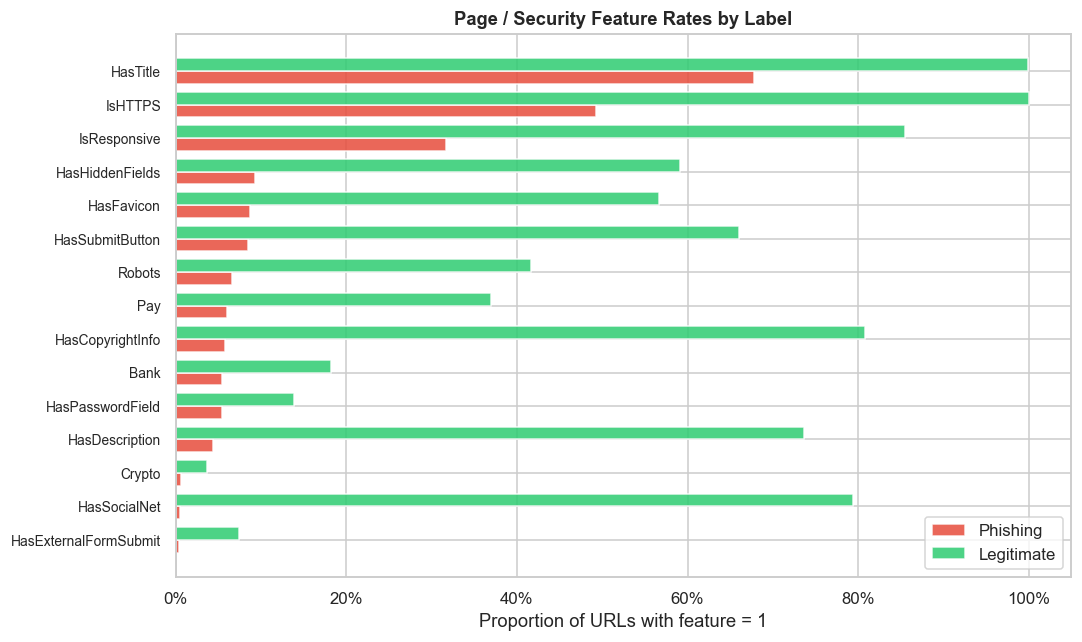

In [32]:
page_features = ['IsHTTPS', 'HasFavicon', 'Robots', 'IsResponsive', 'HasTitle',
                 'HasDescription', 'HasCopyrightInfo', 'HasSocialNet',
                 'HasSubmitButton', 'HasPasswordField', 'HasExternalFormSubmit',
                 'HasHiddenFields', 'Bank', 'Pay', 'Crypto']
page_features = [c for c in page_features if c in df.columns]

pg_rates = (
    df[page_features + ['label']]
    .groupby('label')[page_features]
    .mean()
    .T
    .rename(columns={0: 'Phishing', 1: 'Legitimate'})
    .sort_values('Phishing')
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pg_rates))
w = 0.38
ax.barh(x - w/2, pg_rates['Phishing'],   w, label='Phishing',   color='#e74c3c', alpha=0.85)
ax.barh(x + w/2, pg_rates['Legitimate'], w, label='Legitimate', color='#2ecc71', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(pg_rates.index, fontsize=9)
ax.set_xlabel('Proportion of URLs with feature = 1')
ax.set_title('Page / Security Feature Rates by Label', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

## 13. Redirect & iFrame Analysis

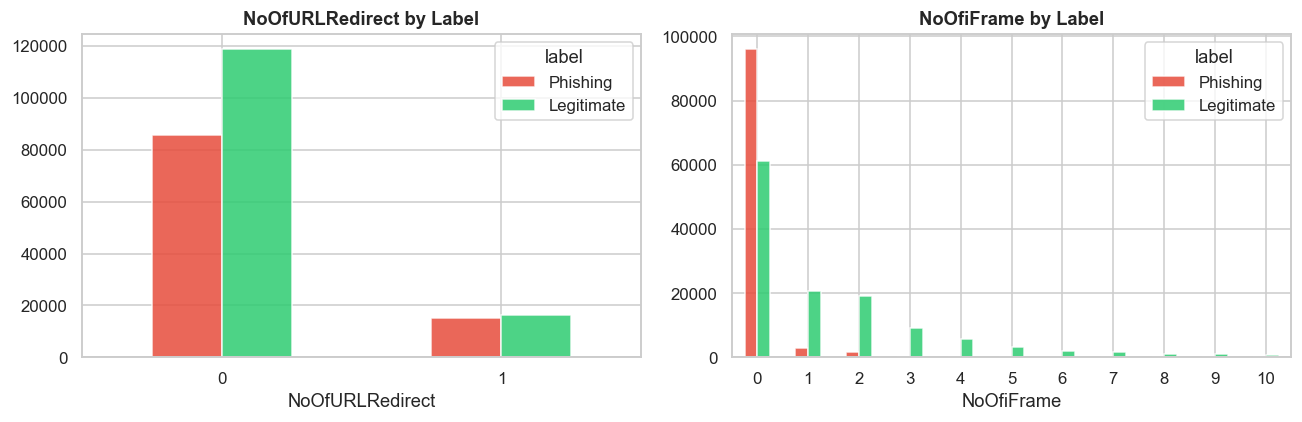

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col, ax in zip(['NoOfURLRedirect', 'NoOfiFrame'], axes):
    counts = (
        df[df[col] <= 10]
        .groupby([col, 'label'])
        .size()
        .unstack(fill_value=0)
        .rename(columns={0: 'Phishing', 1: 'Legitimate'})
    )
    counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} by Label', fontweight='bold')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 14. Summary: Key EDA Findings

Run the cell below to auto-generate a summary table of mean feature values by label.

In [34]:
summary = df[num_cols + ['label']].groupby('label')[num_cols].mean().T
summary.columns = ['Phishing (mean)', 'Legitimate (mean)']
summary['Diff (Leg - Phish)'] = summary['Legitimate (mean)'] - summary['Phishing (mean)']
summary['Abs Diff'] = summary['Diff (Leg - Phish)'].abs()

print('=== Top 20 Features with Largest Mean Difference ===')
display(
    summary.sort_values('Abs Diff', ascending=False)
    .head(20)
    .drop(columns='Abs Diff')
    .round(4)
    .style.background_gradient(subset='Diff (Leg - Phish)', cmap='RdYlGn', vmin=-1, vmax=1)
)

=== Top 20 Features with Largest Mean Difference ===


AttributeError: The '.style' accessor requires jinja2